## Conceptual DMD figures

Apply untruncated exact DMD to a noise-free, unresolved synthetic record and compare its matched modes with the known inputs. Each SV mode is converted from the Felix Alfvén-unit convention to nT yr$^{-1}$ and then given the saved CHAOS water-level scaling used in the main results.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Imports and project setup
import os
import pickle
import sys
from pathlib import Path

cwd = Path(os.getcwd())
PROJECT_ROOT = cwd.resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import numpy as np

from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *
from src.msc_thesis.synFigures import *

['/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_th

### Ideal input record and untruncated DMD

The theoretical phasors use the resolution-record origin (1997.1). The ideal record is therefore evaluated at `times_evaluate_ideal_phasors`, while DMD treats its first supplied snapshot (year 2000) as time zero.

In [3]:
# Demonstration settings
mode_numbers = ["62", "6", "13", "48", "45", "1", "32"]
demo_mode = "48"
demo_time = 30
nmax = 15
svd_rank = -1  # PyDMD convention: no SVD truncation

dmd_settings = {
    "dmd_type": "exact",
    "hankel_flag": False,
    "embedding_d": 0,
    "weight_flag": True,
}

A_r = Truncate_Gauss_Coeffs(A_15_r, tmax=nmax)

input_mode_info = {}
input_mode_records = {}

for mode_key in mode_numbers:
    mode_data = Component_Load_SV(mode_key, nmax=nmax)
    eigenvalue = complex(mode_data["eigenvalue"])
    amplitude_scaler = float(mode_amp_scalings[mode_key])
    gauss_phasor = (
        amplitude_scaler
        * np.asarray(mode_data["gnm"], dtype=complex)
    )
    ideal_record_i = G_Time_Series_Eval(
        gauss_phasor,
        eigenvalue,
        times=times_evaluate_ideal_phasors,
    )

    input_mode_records[mode_key] = ideal_record_i
    input_mode_info[mode_key] = {
        "true_period": float(2 * np.pi / np.abs(eigenvalue.imag)),
        "true_eigenvalue": eigenvalue,
        "amplitude_scaler": amplitude_scaler,
        "gnm_phasor": gauss_phasor,
        "gnm_ideal": ideal_record_i,
    }

ideal_record = np.sum(
    np.stack(list(input_mode_records.values())), axis=0
)
ideal_record_physical = A_r @ ideal_record.T

recovered_modes = Run_DMD(
    ideal_record_physical,
    times_used_relative,
    svd_rank=svd_rank,
    dmd_settings=dmd_settings,
)

match_results, unmatched_periods = Match_Input_Output_Modes(
    input_mode_info,
    recovered_modes,
    nmax=nmax,
    syn_record=True,
    record_key="ideal",
)

print(f"Ideal record shape: {ideal_record.shape}")
print(f"DMD effective rank: {recovered_modes['effective_rank']}")
print(f"Processed DMD modes: {len(recovered_modes['phasors'])}")
print(f"Accepted matches: {match_results['match_count']}/{len(mode_numbers)}")

Ideal record shape: (49, 255)
DMD effective rank: 48
Processed DMD modes: 25
Accepted matches: 7/7


/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 1.1611503401475876e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


In [4]:
# Recover the output index associated with each accepted match.
# Match_Input_Output_Modes stores the matched period and similarity, but
# not the output index itself. Among outputs with the stored period, the
# highest phasor similarity identifies the selected output.
matched_modes = {}
recovered_periods = np.asarray(recovered_modes["periods"])
recovered_phasors = np.asarray(recovered_modes["phasors"])
recovered_eigenvalues = np.asarray(
    recovered_modes["continuous_eigenvalues"]
)

for mode_key in mode_numbers:
    result = match_results[mode_key]
    if not result:
        continue

    input_grid_phasor = A_r @ input_mode_info[mode_key]["gnm_phasor"]
    period_candidates = np.flatnonzero(
        np.isclose(
            recovered_periods,
            result["match_period"],
            rtol=1e-10,
            atol=1e-12,
        )
    )
    if period_candidates.size == 0:
        period_candidates = np.asarray([
            np.argmin(np.abs(recovered_periods - result["match_period"]))
        ])

    candidate_similarities = np.asarray([
        Complex_Phasor_Compare(
            input_grid_phasor, recovered_phasors[index]
        )
        for index in period_candidates
    ])
    output_index = int(
        period_candidates[np.argmax(candidate_similarities)]
    )

    matched_modes[mode_key] = {
        "output_index": output_index,
        "phasor": recovered_phasors[output_index],
        "eigenvalue": recovered_eigenvalues[output_index],
        "period": recovered_periods[output_index],
        "similarity": result["match_similarity"],
    }

matched_indices = [
    mode["output_index"] for mode in matched_modes.values()
]
if len(matched_indices) != len(set(matched_indices)):
    raise ValueError("Accepted inputs do not map to unique DMD outputs")

print("Matched modes:")
for mode_key, mode in matched_modes.items():
    print(
        f"  {mode_key}: T_in="
        f"{input_mode_info[mode_key]['true_period']:.3f} yr, "
        f"T_DMD={mode['period']:.3f} yr, "
        f"similarity={mode['similarity']:.6f}"
    )

missing_modes = [
    mode_key for mode_key in mode_numbers if mode_key not in matched_modes
]
if missing_modes:
    print(f"Unmatched inputs: {missing_modes}")

Matched modes:
  62: T_in=3.506 yr, T_DMD=3.506 yr, similarity=1.000000
  6: T_in=52.863 yr, T_DMD=52.863 yr, similarity=1.000000
  13: T_in=38.773 yr, T_DMD=38.773 yr, similarity=1.000000
  48: T_in=7.086 yr, T_DMD=7.086 yr, similarity=1.000000
  45: T_in=9.452 yr, T_DMD=9.452 yr, similarity=1.000000
  1: T_in=71.071 yr, T_DMD=71.071 yr, similarity=1.000000
  32: T_in=15.221 yr, T_DMD=15.221 yr, similarity=1.000000


### Input and matched-output snapshots

The snapshot scale is set from the cumulative and individual input fields, rounded up to the nearest 1000 nT yr$^{-1}$, and then carried forward unchanged to every matched-output field. Each panel is exported as a transparent SVG for assembly in Inkscape.

In [5]:
# Evaluate ideal and matched DMD components at the shared demonstration time.
input_snapshot_fields = {
    mode_key: (
        A_r @ input_mode_records[mode_key][demo_time]
    ).reshape(state_shape)
    for mode_key in mode_numbers
}
input_total_field = (
    A_r @ ideal_record[demo_time]
).reshape(state_shape)

dmd_time = times_used_relative[demo_time]
matched_snapshot_fields = {}
for mode_key, mode in matched_modes.items():
    snapshot = np.real(
        np.exp(mode["eigenvalue"] * dmd_time) * mode["phasor"]
    )
    matched_snapshot_fields[mode_key] = snapshot.reshape(state_shape)

if not matched_snapshot_fields:
    raise ValueError("No DMD modes passed the matching criteria")

matched_total_field = np.sum(
    np.stack(list(matched_snapshot_fields.values())), axis=0
)
snapshot_relative_error = (
    np.linalg.norm(matched_total_field - input_total_field)
    / np.linalg.norm(input_total_field)
)
print(
    f"Matched-total relative error at year "
    f"{times_used[demo_time]:.1f}: {snapshot_relative_error:.3e}"
)

input_scale_fields = [input_total_field] + [
    input_snapshot_fields[mode_key] for mode_key in mode_numbers
]
snapshot_limit_raw = float(
    np.max(np.abs(np.stack(input_scale_fields)))
)
snapshot_limit = float(
    np.ceil(snapshot_limit_raw / 1000.0) * 1000.0
)
if snapshot_limit <= 0:
    raise ValueError("Snapshot colour limit must be positive")
print(
    f"Input-derived snapshot limit: {snapshot_limit:.0f} "
    r"nT yr$^{-1}$"
)

plot_longitude = (longitude + 180) % 360 - 180
longitude_order = np.argsort(plot_longitude)
longitude_cyclic = np.append(plot_longitude[longitude_order], 180)

element_directory = (
    Path(RESULT_DIR) / "conceptual_dmd_elements"
)
element_directory.mkdir(parents=True, exist_ok=True)

cumulative_map_width = text_width / 3
component_map_width = text_width / 4

def plot_world_field(ax, field, cmap, limit, title=None):
    field_sorted = field[:, longitude_order]
    field_cyclic = np.column_stack(
        (field_sorted, field_sorted[:, 0])
    )
    image = ax.pcolormesh(
        np.deg2rad(longitude_cyclic),
        np.deg2rad(latitude),
        field_cyclic,
        cmap=cmap,
        vmin=-limit,
        vmax=limit,
        shading="auto",
    )
    if title is not None:
        ax.set_title(title)
    ax.grid(True, color="0.7", linewidth=0.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.patch.set_alpha(0)
    return image

def save_world_element(field, title, filename, width, cmap, limit):
    height_ratio = 0.62 if title is not None else 0.52
    fig, ax = plt.subplots(
        figsize=(width, height_ratio * width),
        subplot_kw={"projection": "mollweide"},
        constrained_layout=True,
    )
    fig.patch.set_alpha(0)
    plot_world_field(
        ax, field, cmap=cmap, limit=limit, title=title
    )
    fig.savefig(
        element_directory / filename,
        transparent=True,
        bbox_inches="tight",
        pad_inches=0.10,
    )
    plt.close(fig)

def save_horizontal_colourbar(
    filename, width, cmap, limit, label
):
    fig, colourbar_ax = plt.subplots(
        figsize=(width, 0.11 * text_width)
    )
    fig.patch.set_alpha(0)
    colourbar_ax.patch.set_alpha(0)
    fig.subplots_adjust(
        left=0.10, right=0.90, bottom=0.52, top=0.78
    )
    scalar_mappable = ScalarMappable(
        norm=Normalize(vmin=-limit, vmax=limit), cmap=cmap
    )
    scalar_mappable.set_array([])
    colourbar = fig.colorbar(
        scalar_mappable, cax=colourbar_ax, orientation="horizontal"
    )
    colourbar.set_ticks([-limit, 0, limit])
    colourbar.set_label(label)
    fig.savefig(
        element_directory / filename,
        transparent=True,
        bbox_inches="tight",
        pad_inches=0.10,
    )
    plt.close(fig)

save_world_element(
    input_total_field,
    "Cumulative input",
    "input_cumulative.svg",
    cumulative_map_width,
    cmap="seismic",
    limit=snapshot_limit,
)
for mode_key in mode_numbers:
    save_world_element(
        input_snapshot_fields[mode_key],
        f"Wave {mode_key}",
        f"input_mode_{mode_key}.svg",
        component_map_width,
        cmap="seismic",
        limit=snapshot_limit,
    )

Matched-total relative error at year 2015.0: 3.064e-11
Input-derived snapshot limit: 19000 nT yr$^{-1}$


In [6]:
matched_keys = list(matched_modes)
save_world_element(
    matched_total_field,
    "DMD reconstruction",
    "dmd_reconstruction.svg",
    cumulative_map_width,
    cmap="seismic",
    limit=snapshot_limit,
)

output_mode_mapping = {}
for output_number, mode_key in enumerate(matched_keys, start=1):
    output_mode_mapping[f"Mode {output_number}"] = mode_key
    save_world_element(
        matched_snapshot_fields[mode_key],
        f"Output Mode {output_number}",
        f"dmd_mode_{output_number:02d}.svg",
        component_map_width,
        cmap="seismic",
        limit=snapshot_limit,
    )

save_horizontal_colourbar(
    "snapshot_colourbar.svg",
    cumulative_map_width,
    cmap="seismic",
    limit=snapshot_limit,
    label=r"Radial SV (nT yr$^{-1}$)",
)
print(f"DMD display-mode mapping: {output_mode_mapping}")

DMD display-mode mapping: {'Mode 1': '62', 'Mode 2': '6', 'Mode 3': '13', 'Mode 4': '48', 'Mode 5': '45', 'Mode 6': '1', 'Mode 7': '32'}


### Phase-aligned mode 48 phasors

The input phasor is propagated from the 1997.1 reference epoch to year 2000. The DMD phasor already refers to year 2000 because its dynamically scaled amplitudes are tied to the first input snapshot.

In [7]:
if demo_mode not in matched_modes:
    raise ValueError(f"Mode {demo_mode} was not matched by DMD")

input_eigenvalue = input_mode_info[demo_mode]["true_eigenvalue"]
reference_time_shift = times_used[0] - times_res[0]
input_phasor_2000 = (
    input_mode_info[demo_mode]["gnm_phasor"]
    * np.exp(input_eigenvalue * reference_time_shift)
)
input_grid_phasor_2000 = A_r @ input_phasor_2000

dmd_grid_phasor_2000 = matched_modes[demo_mode]["phasor"]
dmd_eigenvalue = matched_modes[demo_mode]["eigenvalue"]

phasor_fields = np.asarray([
    input_grid_phasor_2000.real.reshape(state_shape),
    input_grid_phasor_2000.imag.reshape(state_shape),
    dmd_grid_phasor_2000.real.reshape(state_shape),
    dmd_grid_phasor_2000.imag.reshape(state_shape),
])
phasor_limit_raw = float(np.max(np.abs(phasor_fields)))
phasor_limit = float(
    np.ceil(phasor_limit_raw / 100.0) * 100.0
)
if phasor_limit <= 0:
    raise ValueError("Phasor colour limit must be positive")
print(
    f"Shared phasor limit: {phasor_limit:.0f} "
    r"nT yr$^{-1}$"
)
print(f"Input eigenvalue at 2000 reference: {input_eigenvalue}")
print(f"Matched DMD eigenvalue: {dmd_eigenvalue}")

phasor_assets = [
    (phasor_fields[0], "mode_48_input_phasor_real.svg"),
    (phasor_fields[1], "mode_48_input_phasor_imaginary.svg"),
    (phasor_fields[2], "mode_48_dmd_phasor_real.svg"),
    (phasor_fields[3], "mode_48_dmd_phasor_imaginary.svg"),
]
for phasor_field, filename in phasor_assets:
    save_world_element(
        phasor_field,
        title=None,
        filename=filename,
        width=component_map_width,
        cmap="PuOr",
        limit=phasor_limit,
    )

save_horizontal_colourbar(
    "phasor_colourbar.svg",
    component_map_width,
    cmap="PuOr",
    limit=phasor_limit,
    label=r"Radial SV phasor (nT yr$^{-1}$)",
)
print(f"Saved conceptual DMD elements to {element_directory}")

Shared phasor limit: 1400 nT yr$^{-1}$
Input eigenvalue at 2000 reference: 0.8866635855791295j
Matched DMD eigenvalue: 0.8866635855791293j
Saved conceptual DMD elements to /home/elliott/projects/msc_thesis_project/results/conceptual_dmd_elements


### Full-match similarity threshold

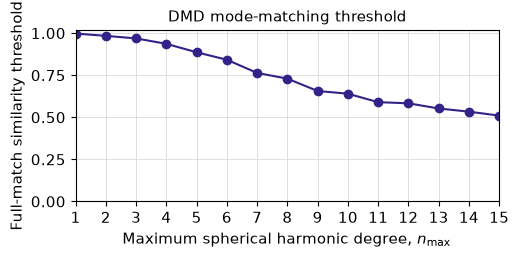

In [8]:
match_metric_path = Path(FELIX_DIR) / "match_metrics.pkl"
with open(match_metric_path, "rb") as file:
    saved_similarity_thresholds = pickle.load(file)

full_match_thresholds = saved_similarity_thresholds["full_match"]
threshold_degrees = np.asarray(
    sorted(int(key) for key in full_match_thresholds)
)
threshold_values = np.asarray([
    full_match_thresholds[str(degree)]
    for degree in threshold_degrees
])

fig, ax = plt.subplots(
    figsize=(0.7 * text_width, 0.34 * text_width),
    constrained_layout=True,
)
ax.plot(
    threshold_degrees,
    threshold_values,
    color=tol_muted[0],
    marker="o",
    markerfacecolor=tol_muted[0],
    markeredgecolor=tol_muted[0],
)
ax.set(
    xlabel=r"Maximum spherical harmonic degree, $n_{\max}$",
    ylabel="Full-match similarity threshold",
    title="DMD mode-matching threshold",
    xlim=(1, 15),
    ylim=(0, 1.02),
    xticks=threshold_degrees,
)
ax.grid(True, color="0.85", linewidth=0.6)
fig.savefig(
    Path(RESULT_DIR) / "conceptual_dmd_full_match_threshold.pdf",
    bbox_inches="tight",
)
plt.show()